In [15]:
from modules.core.features.preprocessing import canon_smiles
import os

import pandas as pd

# Load data
main_dir = '../../../data'
data_types = {
    'expert': 'data_experts1.csv',
    'expert2': 'data_experts2.csv',
    'expert3': 'data_experts3.csv',
    'zhu': 'data_zhu.csv',
    'saad': 'data_saad.csv',
}
min_smiles = {}
for dtype in data_types:
    print(dtype)
    df = pd.read_csv(os.path.join(main_dir, 'raw', data_types[dtype]))
    df.columns = [x.lower() for x in df.columns]
    df['smiles'] = df['smiles'].apply(canon_smiles)
    df.dropna(subset=['smiles'], inplace=True)
    df.drop_duplicates(subset=['smiles'], inplace=True)
    min_smiles[dtype] = df['smiles'].tolist()

expert
expert2
expert3
zhu
saad


[14:48:31] Explicit valence for atom # 5 C, 5, is greater than permitted
[14:48:31] SMILES Parse Error: syntax error while parsing: CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].
[14:48:31] SMILES Parse Error: Failed parsing SMILES 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].' for input: 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].'
[14:48:31] SMILES Parse Error: syntax error while parsing: CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].
[14:48:31] SMILES Parse Error: Failed parsing SMILES 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].' for input: 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].'
[14:48:31] SMILES Parse Error: syntax error while parsing: CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].
[14:48:31] SMILES Parse Error: Failed parsing SMILES 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].' for input: 'CC1=NC=C[N-]1.CC1=NC=C[N-]1.[Zn+2].'
[14:48:31] Explicit valence for atom # 11 O, 3, is greater than permitted
[14:48:31] Explicit valence for atom # 19 O, 3, is greater than permitted
[14:48:31] Explicit valence for atom # 19 O, 3, is greater than permitted


In [16]:
min_smiles

{'expert': ['CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(C#N)cc2)n3-c2ccc(C(C)C)cc2)cc1',
  'N#Cc1ccc(C#N)cc1',
  'N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1',
  'Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C#N)cc3)n4-c3nc4ccc(C)cc4s3)sc2c1',
  'N#Cc1ccc(-c2cc3c(cc(-c4ccc(C#N)cc4)n3-c3ccc(C#N)cc3)n2-c2ccc(C#N)cc2)cc1',
  'Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4ccccc4)c3)cc2)n1',
  'N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(C#N)cc5)c(=O)c4cc3c2=O)cc1',
  'N#Cc1cncc(C#N)c1',
  'Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Cl)nc(Cl)n3)cc1C2=O',
  'Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1',
  'N#C/C=C/C#N',
  'Nc1cc(O)c(N=Cc2ccc(-c3nc(-c4ccc(C=O)cc4)nc(-c4ccc(C=O)cc4)n3)cc2)cc1O',
  'N#Cc1ccc(-n2[nH]c(=O)c3cc4c(=O)[nH]n(-c5ccc(C#N)cc5)c(=O)c4cc3c2=O)cc1',
  'N#Cc1ccc(-c2ccc(C#N)cc2)cc1',
  'N#Cc1ccc(-c2ccc(C#N)cn2)nc1',
  'N#Cc1cccc(C#N)n1',
  'N#Cc1c(F)c(F)c(C#N)c(F)c1F',
  'Nc1nc(N)nc(N=CN2CCN(C=O)CC2)n1',
  'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(-n4c(=O)c5cc6c(=O)oc(=O)c6cc5c4=O)cc3)n2)cc1',
  'Nc1ccc(-c2nc(-c3ccc(N)

In [17]:
for dtype, dlist in min_smiles.items():
    print(dtype, len(dlist))

expert 26
expert2 22
expert3 29
zhu 24
saad 2


In [18]:
for subdir in [s for s in os.listdir(main_dir) if s not in ['sampling', 'raw', 'symmetries', 'processed_all_custom_features']]:
    print(subdir)
    for dtype, dfile in data_types.items():
        df = pd.read_csv(os.path.join(main_dir, subdir, dfile))
        df.columns = [x.lower() for x in df.columns]
        df['smiles'] = df['smiles'].apply(canon_smiles)
        df.dropna(subset=['smiles'], inplace=True)
        df.drop_duplicates(subset=['smiles'], inplace=True)
        smiles_file = df['smiles'].tolist()
        smiles_now = min_smiles[dtype]
        print(len(smiles_now), len(smiles_file), len([x for x in smiles_now if x in smiles_file]))
        new_smiles = [x for x in smiles_now if x in smiles_file]
        min_smiles[dtype] = new_smiles

fingerprints_layered
26 24 24
22 22 22
29 29 29
24 21 20
2 1 1
fingerprints_topological
24 24 24
22 22 22
29 29 29
20 21 20
1 1 1
fingerprints_maccs
24 24 24
22 22 22
29 29 29
20 21 20
1 1 1
fingerprints_layered_512
24 24 24
22 22 22
29 29 29
20 20 19
1 1 1
aggregated_dft_features
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
custom_features_mlxtend
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
fingerprints_layered_256
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
additive_groups
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
fingerprints_topological_512
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
processed_selected_custom_features
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
fingerprints_functional_groups
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
fingerprints_ecfp
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
fingerprints_estate
24 24 24
22 22 22
29 29 29
19 21 19
1 1 1
aggregated_selected_dft_features
24 24 24
22 22 22
29 29 29
19 20 19
1 1 1
fingerprints_topological_256
24 24 24
22 22 22
29 29 29
19 21 19
1 

In [19]:
for dtype, dlist in min_smiles.items():
    print(dtype, len(dlist))

expert 24
expert2 22
expert3 29
zhu 19
saad 1


In [26]:
for subdir in [s for s in os.listdir(main_dir) if s not in ['sampling', 'raw', 'symmetries', 'processed_all_custom_features']]:
    print(subdir)
    for dtype, dfile in data_types.items():
        df = pd.read_csv(os.path.join(main_dir, subdir, dfile))
        df.columns = [x.lower() for x in df.columns]
        df['smiles'] = df['smiles'].apply(canon_smiles)
        df.dropna(subset=['smiles'], inplace=True)
        df.drop_duplicates(subset=['smiles'], inplace=True)
        df = df[df['smiles'].isin(min_smiles[dtype])]
        print(dtype, subdir, len(df))
        df.to_csv(os.path.join(main_dir, subdir, dfile), index=False)

fingerprints_layered
expert fingerprints_layered 24
expert2 fingerprints_layered 22
expert3 fingerprints_layered 29
zhu fingerprints_layered 19
saad fingerprints_layered 1
fingerprints_topological
expert fingerprints_topological 24
expert2 fingerprints_topological 22
expert3 fingerprints_topological 29
zhu fingerprints_topological 19
saad fingerprints_topological 1
fingerprints_maccs
expert fingerprints_maccs 24
expert2 fingerprints_maccs 22
expert3 fingerprints_maccs 29
zhu fingerprints_maccs 19
saad fingerprints_maccs 1
fingerprints_layered_512
expert fingerprints_layered_512 24
expert2 fingerprints_layered_512 22
expert3 fingerprints_layered_512 29
zhu fingerprints_layered_512 19
saad fingerprints_layered_512 1
aggregated_dft_features
expert aggregated_dft_features 24
expert2 aggregated_dft_features 22
expert3 aggregated_dft_features 29
zhu aggregated_dft_features 19
saad aggregated_dft_features 1
custom_features_mlxtend
expert custom_features_mlxtend 24
expert2 custom_features_mlxt

In [33]:

paths = ['../../../data/processed_selected_custom_features/data_experts1.csv',
         '../../../data/fingerprints_layered/data_experts1.csv',
         ]
df = [pd.read_csv(data_path) for data_path in paths]
result = df[0]
for data in df[1:]:
    data = data.drop(columns=['capacity_max'])
    result = pd.merge(result, data, on='smiles', how='inner')
# df = pd.concat(df, axis=1).reset_index(drop=True)
result.columns = result.columns.str.replace(r"[\[\]>]", "", regex=True)
result =result.loc[:, ~result.columns.duplicated()].sort_values(by="smiles").reset_index(drop=True)
result
#print(df)

,smiles,capacity_max,flatness,ps,%c,%n,%o,mollogp,num_atoms,num_bonds,...,layeredfingerprint118,layeredfingerprint119,layeredfingerprint120,layeredfingerprint121,layeredfingerprint122,layeredfingerprint123,layeredfingerprint124,layeredfingerprint125,layeredfingerprint126,layeredfingerprint127
0,C#Cc1ccc(C#N)cc1,628.0,0.158494,1.527471,90.000000,10.000000,0.000000,1.53958,10,10,...,0,1,0,0,1,0,0,1,1,1
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,1.750266,3.422303,90.476190,9.523810,0.000000,9.74536,42,47,...,0,1,1,1,1,1,1,1,1,1
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,269.0,1.674914,3.444589,81.818182,13.636364,0.000000,9.33480,44,51,...,1,1,1,1,1,1,1,1,1,1
3,Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1,196.0,0.690551,2.203633,65.000000,25.000000,0.000000,2.51710,20,22,...,0,1,1,1,1,1,1,0,1,1
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4cccc...,228.0,0.732465,2.853515,84.375000,9.375000,0.000000,7.84640,32,36,...,0,1,1,1,1,1,1,0,1,1
5,N#C/C=C/C#N,404.0,0.028831,1.135324,66.666667,33.333333,0.000000,0.58976,6,5,...,0,0,0,0,1,0,1,0,0,0
6,N#CC(C#N)=c1ccc(=C(C#N)C#N)cc1,383.0,0.341812,1.784802,75.000000,25.000000,0.000000,0.08232,16,16,...,1,1,0,1,1,0,1,1,1,1
7,N#Cc1c(F)c(F)c(C#N)c(F)c1F,379.0,0.013632,1.525033,57.142857,14.285714,0.000000,1.98636,14,14,...,0,1,0,1,1,1,1,1,1,1
8,N#Cc1c2ccccc2c(C#N)c2ccccc12,589.0,0.145855,1.531009,88.888889,11.111111,0.000000,3.73636,18,20,...,0,1,1,1,1,1,0,1,1,1
9,N#Cc1cc(C#N)c2ccc3c(C#N)cc(C#N)c4ccc1c2c43,500.0,0.251508,2.072189,83.333333,16.666667,0.000000,4.07072,24,27,...,0,1,1,1,1,1,0,1,1,1


expert1 196.0 628.0
expert2 5.65 724.0
saad 552 552
zhu 38.0 550.0
expert3 0.0 1236.0


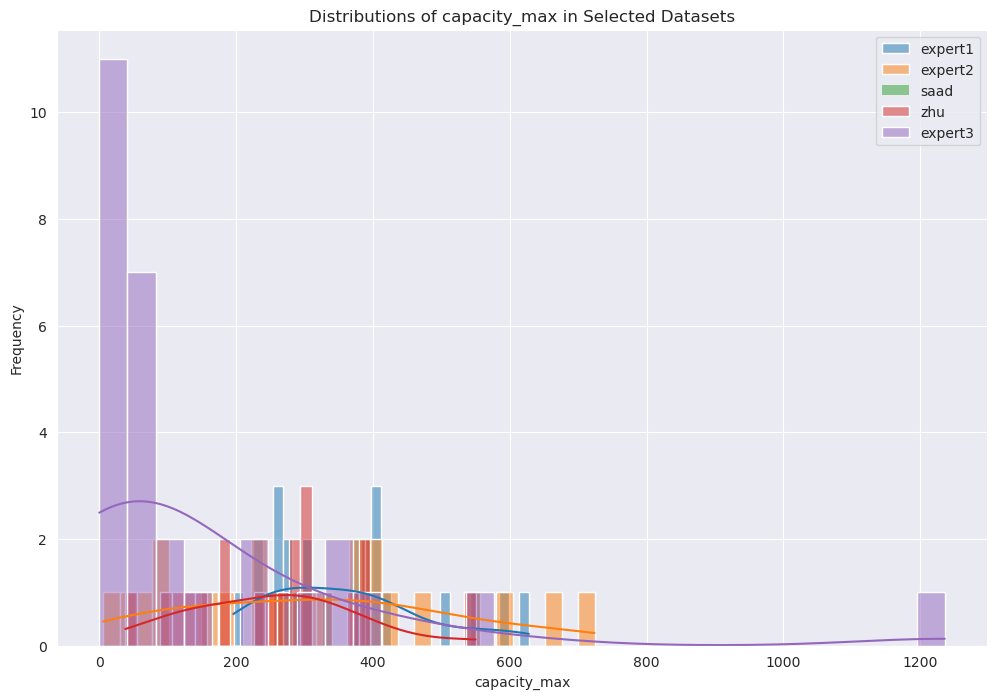

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Plot the distributions of capacity_max

plt.figure(figsize=(12, 8))
for name, df in dfs.items():
    print(name, df['capacity_max'].min(), df['capacity_max'].max())
    sns.histplot(df['capacity_max'], kde=True, label=name, bins=30)

plt.title('Distributions of capacity_max in Selected Datasets')
plt.xlabel('capacity_max')
plt.ylabel('Frequency')
plt.legend()
plt.show()

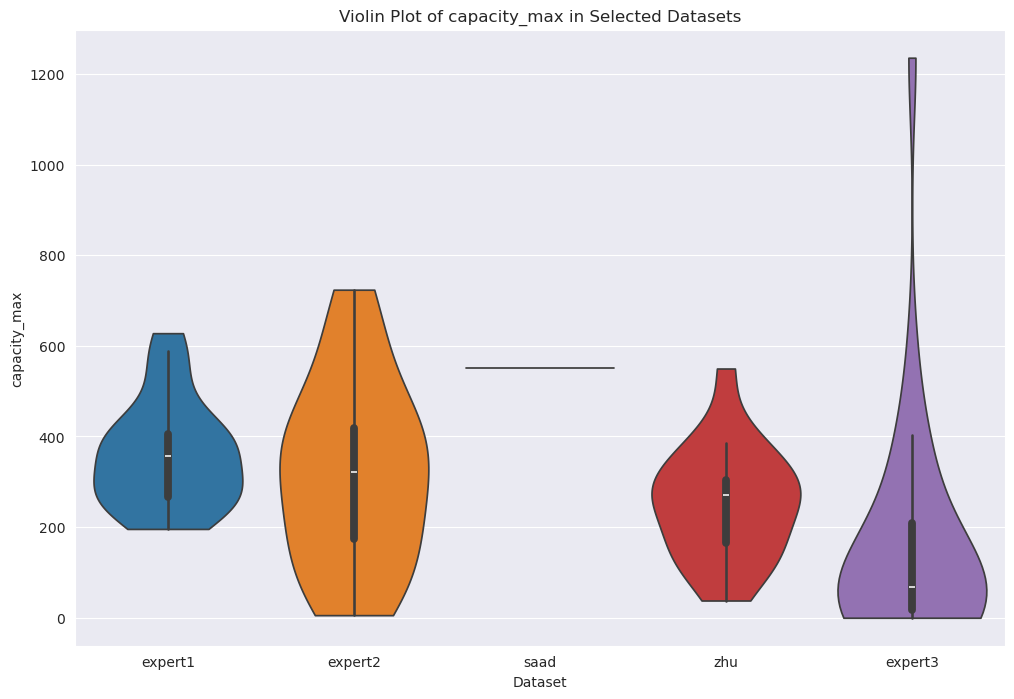

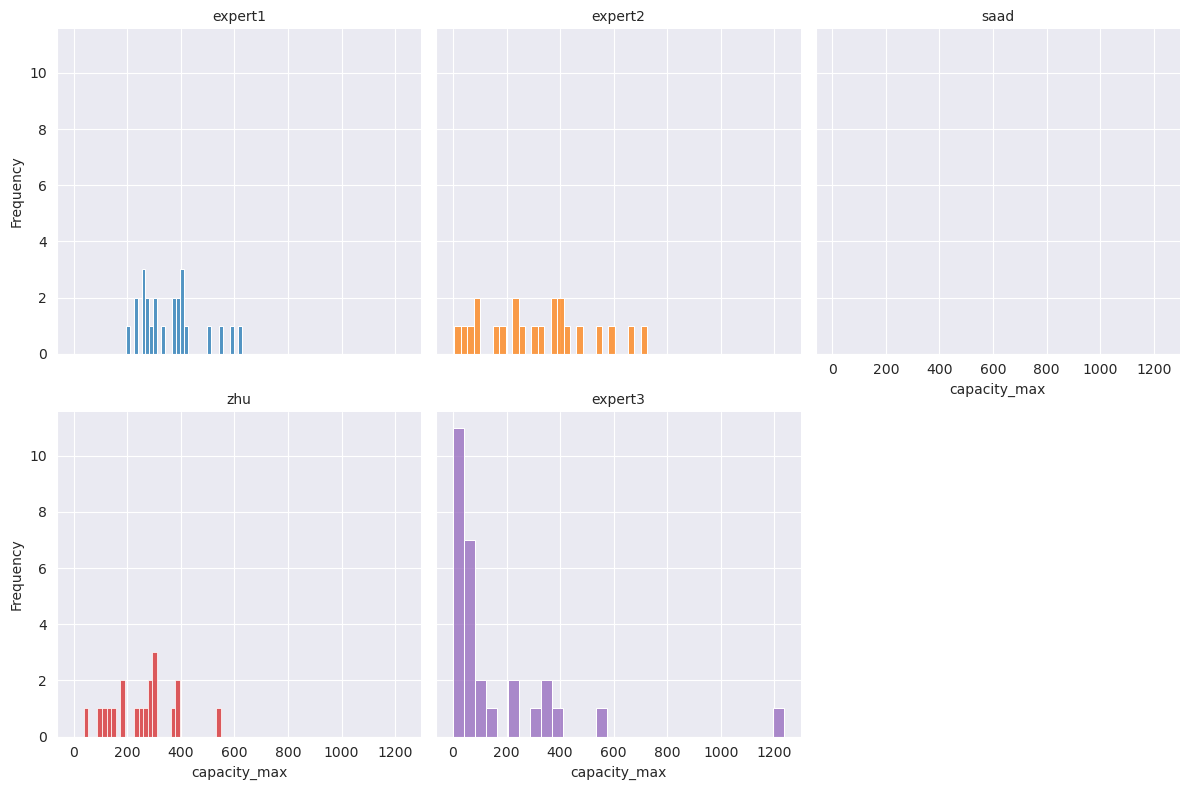

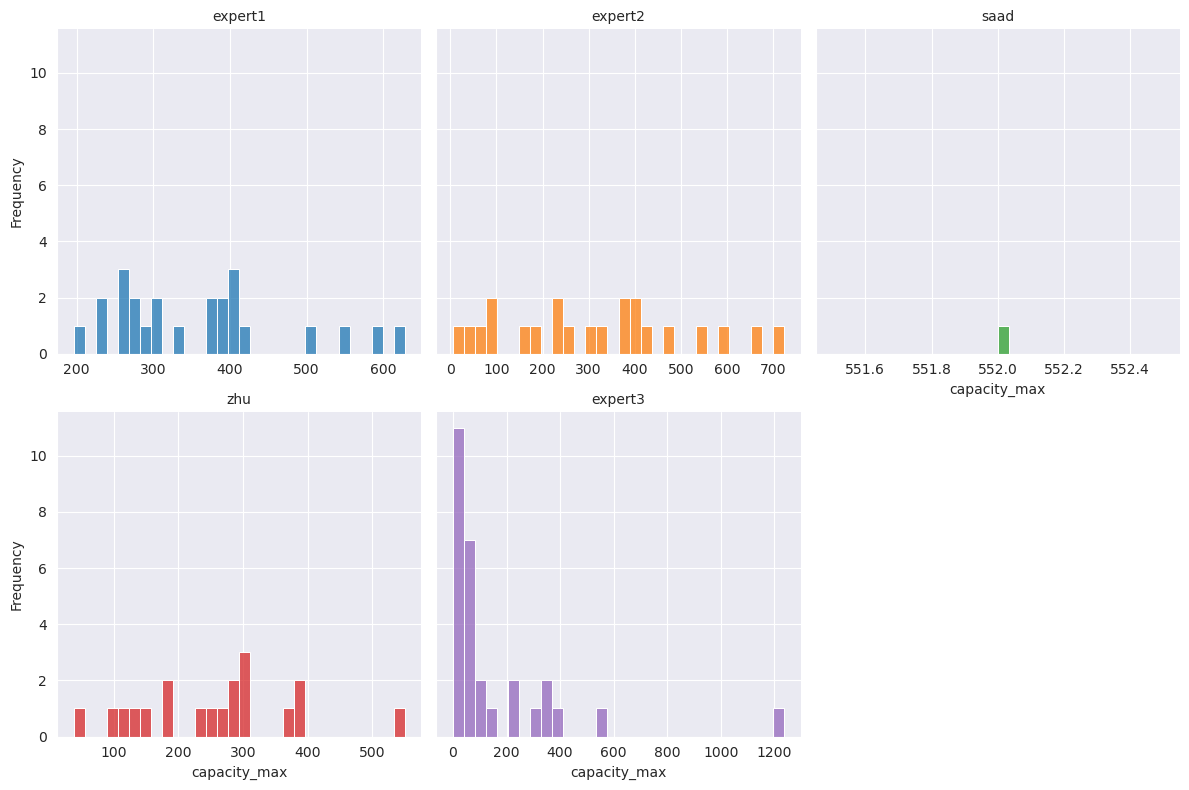

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Combine datasets into a single DataFrame for facet plot
df_combined = pd.concat([df.assign(dataset=name) for name, df in dfs.items()], ignore_index=True)

# Create a violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x='dataset', y='capacity_max', data=df_combined, cut=0, hue='dataset')
plt.title('Violin Plot of capacity_max in Selected Datasets')
plt.xlabel('Dataset')
plt.ylabel('capacity_max')
plt.show()

# Create a facet plot with each dataset on a separate plot
g = sns.FacetGrid(df_combined, col='dataset', col_wrap=3, height=4, sharex=True, sharey=True, hue='dataset')
g.map(sns.histplot, 'capacity_max', kde=False, bins=30)
g.set_titles(col_template="{col_name}")
g.set_axis_labels('capacity_max', 'Frequency')
plt.show()

# Create a facet plot with each dataset on a separate plot
g = sns.FacetGrid(df_combined, col='dataset', col_wrap=3, height=4, sharex=False, sharey=True, hue='dataset')
g.map(sns.histplot, 'capacity_max', kde=False, bins=30)
g.set_titles(col_template="{col_name}")
g.set_axis_labels('capacity_max', 'Frequency')
plt.show()

In [3]:
df = pd.concat(dfs, ignore_index=True)
df

,smiles,capacity_max,flatness,ps,%c,%n,%o,mollogp,num_atoms,num_bonds,num_aromatic_rings,num_heteroatoms,num_rotatable_bonds,num_h_acceptors,num_h_donors,tpsa,mol_wt,symmetry
0,C#Cc1ccc(C#N)cc1,628.0,0.158494,1.527471,90.000000,10.000000,0.000000,1.53958,10,10,1,1,0,1,0,23.79,127.042199,C2v
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,1.750266,3.422303,90.476190,9.523810,0.000000,9.74536,42,47,6,4,6,4,0,57.44,544.262697,C1
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(C...,269.0,1.674914,3.444589,81.818182,13.636364,0.000000,9.33480,44,51,8,8,4,6,0,83.22,602.134737,C1
3,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccccc4)cc(-c4cccc...,228.0,0.732465,2.853515,84.375000,9.375000,0.000000,7.84640,32,36,5,5,4,3,0,38.67,453.079953,C1
4,Clc1nc(Cl)nc(-[n+]2ccc(-c3ccncc3)cc2)n1,196.0,0.690551,2.203633,65.000000,25.000000,0.000000,2.51710,20,22,3,7,2,5,0,55.44,304.015127,C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,O=S1(=O)c2ccc(Br)cc2S(=O)(=O)c2cc(-c3ccc(-c4cc...,52.0,1.708517,4.678455,81.481481,0.000000,7.407407,13.01360,54,61,7,10,7,4,0,68.28,999.816250,C1
91,OB(O)c1cc(B(O)O)c2ccc3c(B(O)O)cc(-c4ccc5c(c4)c...,75.3,2.013054,5.058348,75.757576,6.060606,9.090909,7.89110,66,78,12,16,4,10,6,172.94,1049.983812,C1
92,OB(O)c1ccc(-c2cc(-c3ccc(-c4ccc5c(c4)c4cc(Br)cc...,24.9,1.987410,5.789660,80.281690,7.042254,5.633803,12.20230,71,83,13,14,6,9,4,145.37,1109.019052,C1
93,OB(O)c1ccc(-c2nc(-c3ccc(B(O)O)cc3)nc(-c3ccc(-c...,121.9,1.497801,5.874983,77.464789,9.859155,5.633803,10.99230,71,83,13,16,6,11,4,171.15,1111.009550,C1


In [4]:
num_bins = 6
bins = pd.qcut(df['capacity_max'], q=num_bins, labels=None)
bins

0     (406.333, 1236.0]
1        (169.0, 256.0]
2        (256.0, 335.0]
3        (169.0, 256.0]
4        (169.0, 256.0]
            ...        
90      (51.767, 169.0]
91      (51.767, 169.0]
92     (-0.001, 51.767]
93      (51.767, 169.0]
94      (51.767, 169.0]
Name: capacity_max, Length: 95, dtype: category
Categories (6, interval[float64, right]): [(-0.001, 51.767] < (51.767, 169.0] < (169.0, 256.0] < (256.0, 335.0] < (335.0, 406.333] < (406.333, 1236.0]]

In [5]:
num_bins = 6
bins = pd.cut(df['capacity_max'], bins=num_bins, labels=False)
bins

0     3
1     1
2     1
3     1
4     0
     ..
90    0
91    0
92    0
93    0
94    0
Name: capacity_max, Length: 95, dtype: int64

expert1


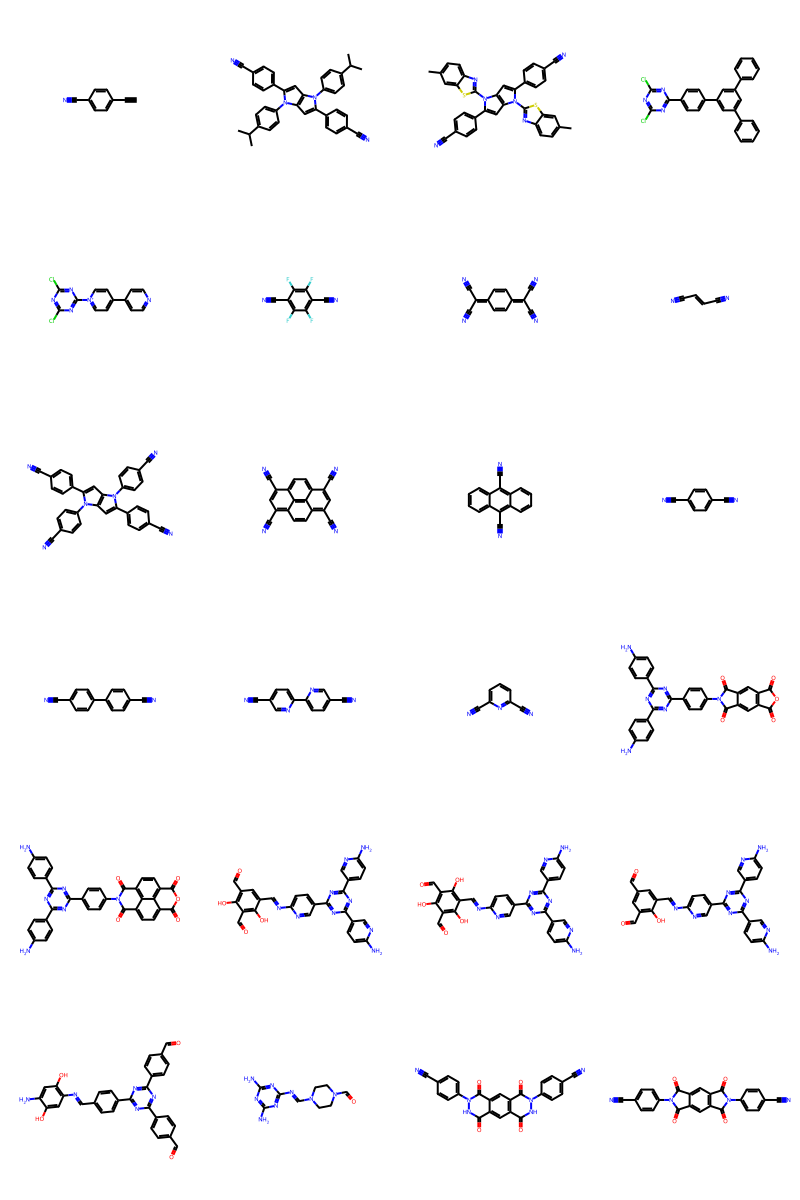

expert2


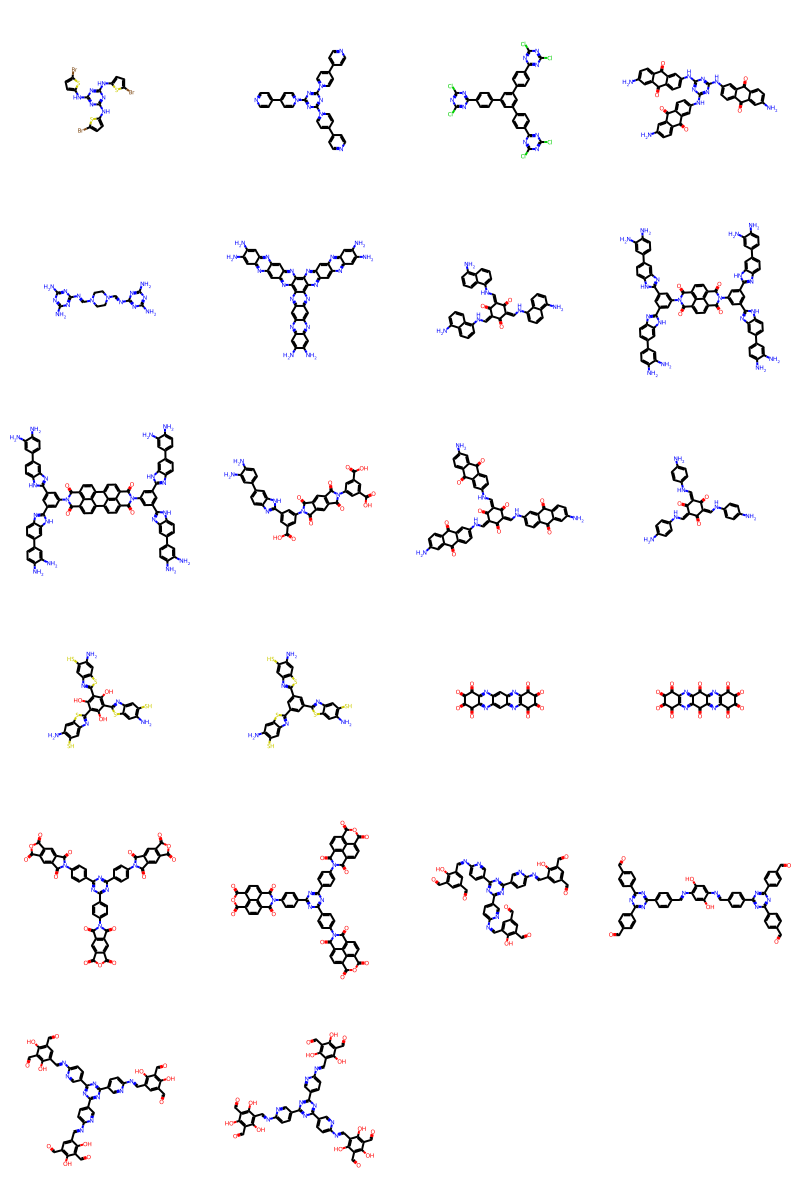

saad


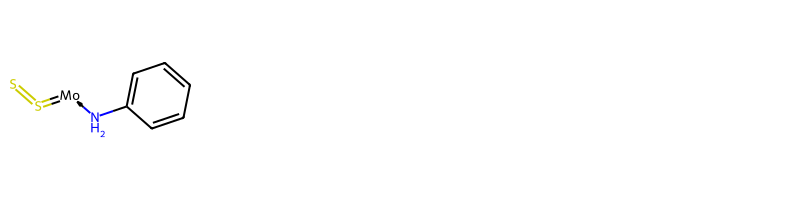

zhu


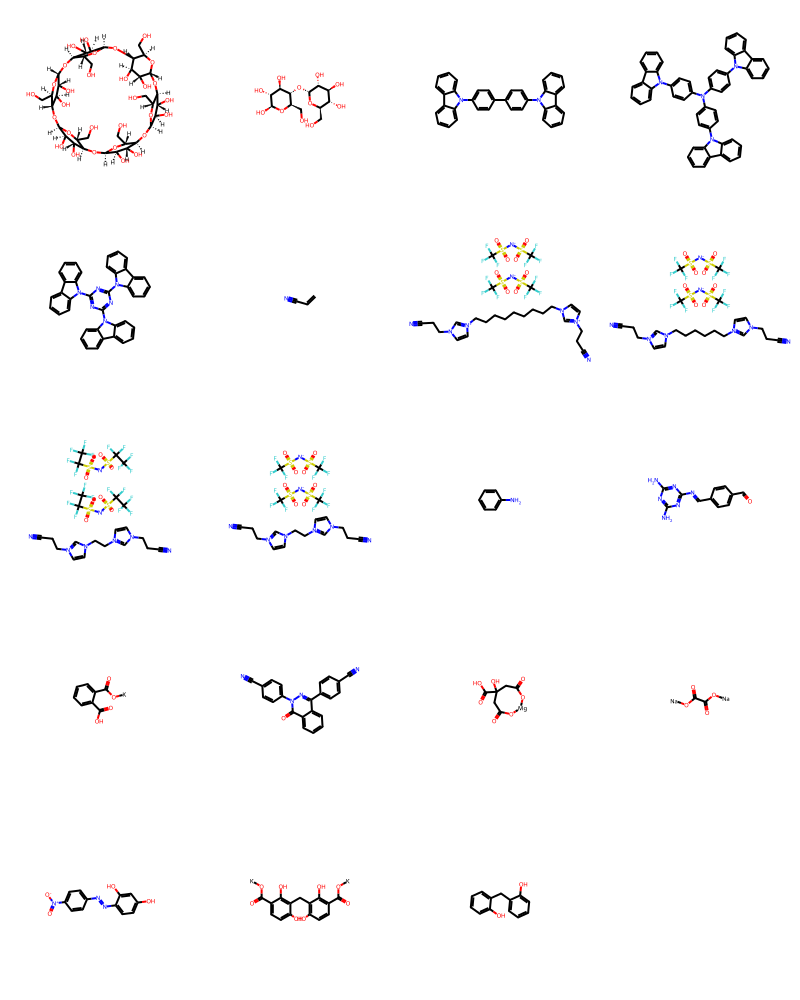

expert3


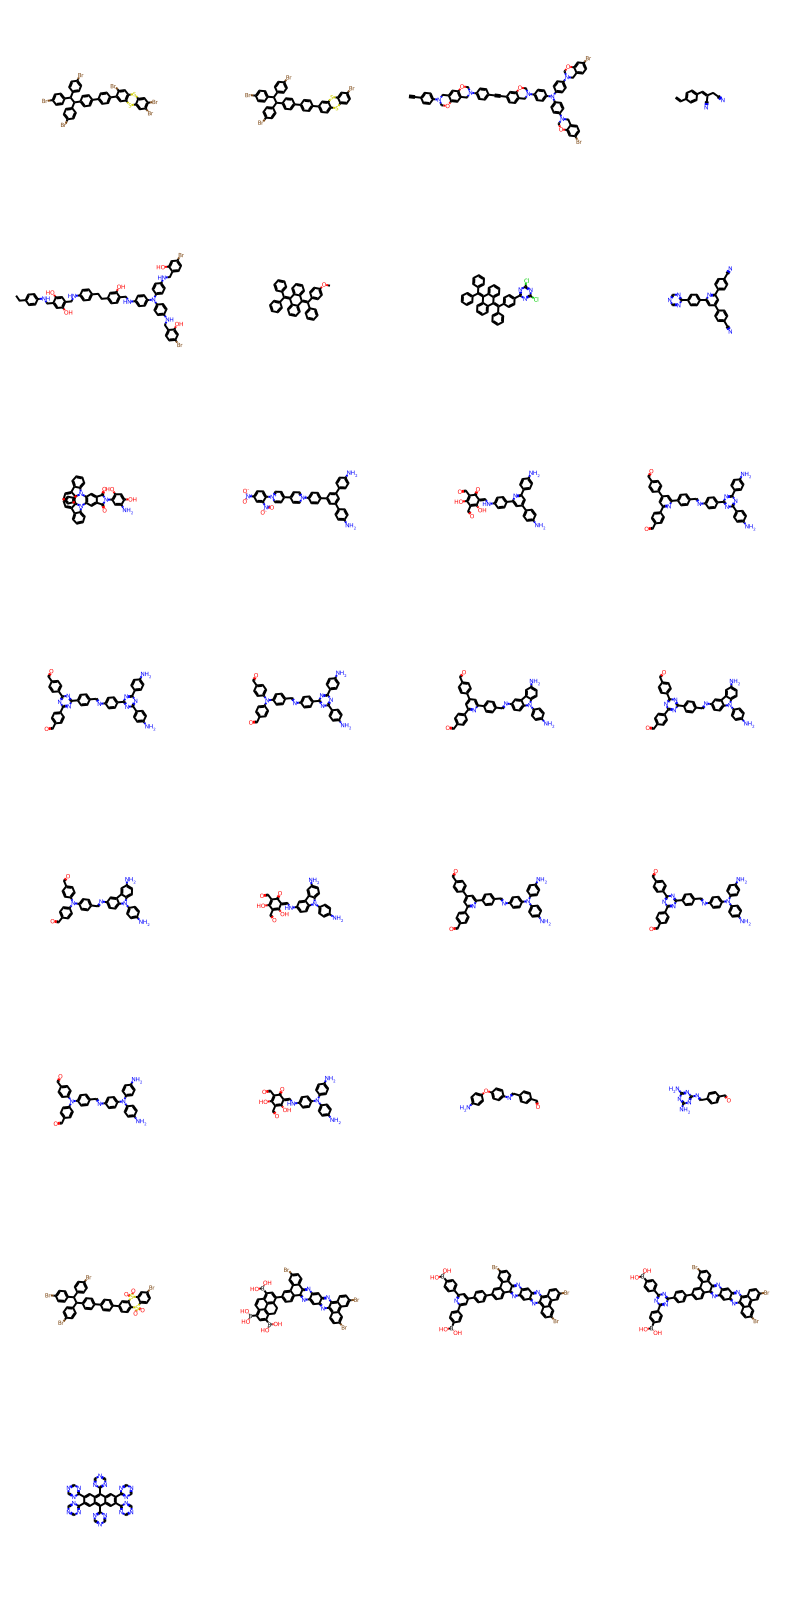

In [4]:
import numpy as np
from rdkit.Chem import Draw
from rdkit import Chem
import pandas as pd


data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}
for data_name, df_path in data_paths.items():
    df_small = pd.read_csv(df_path)
    print(data_name)
    smiles = df_small['smiles'].tolist()
    mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    display(Draw.MolsToGridImage(mols, molsPerRow=4))

0 0.0 196.0 36


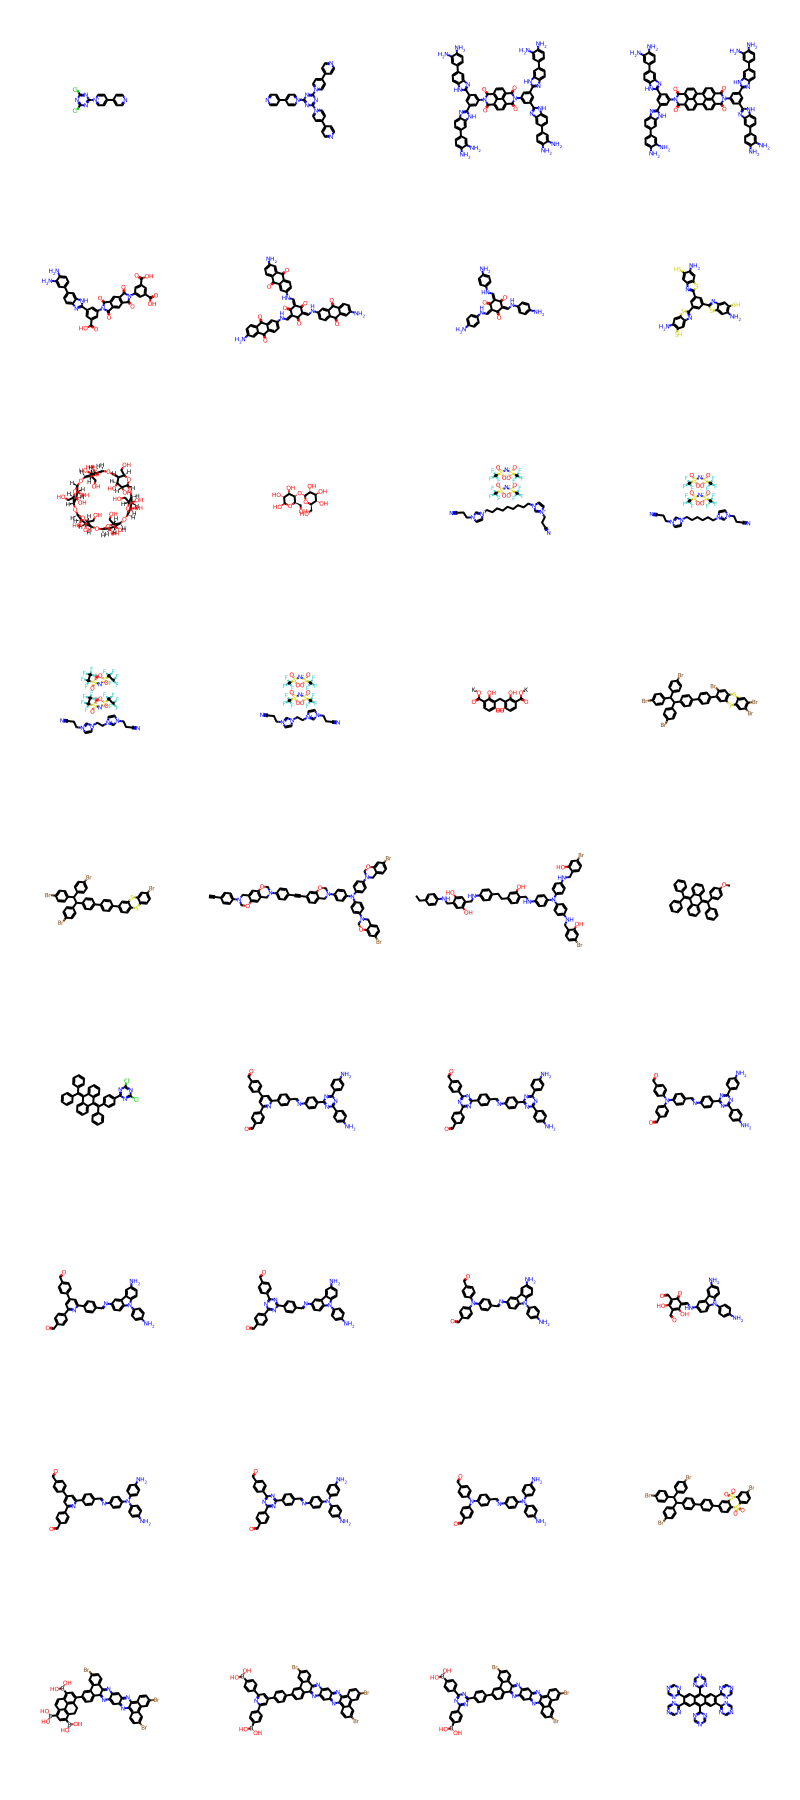

1 209.0 407.0 44


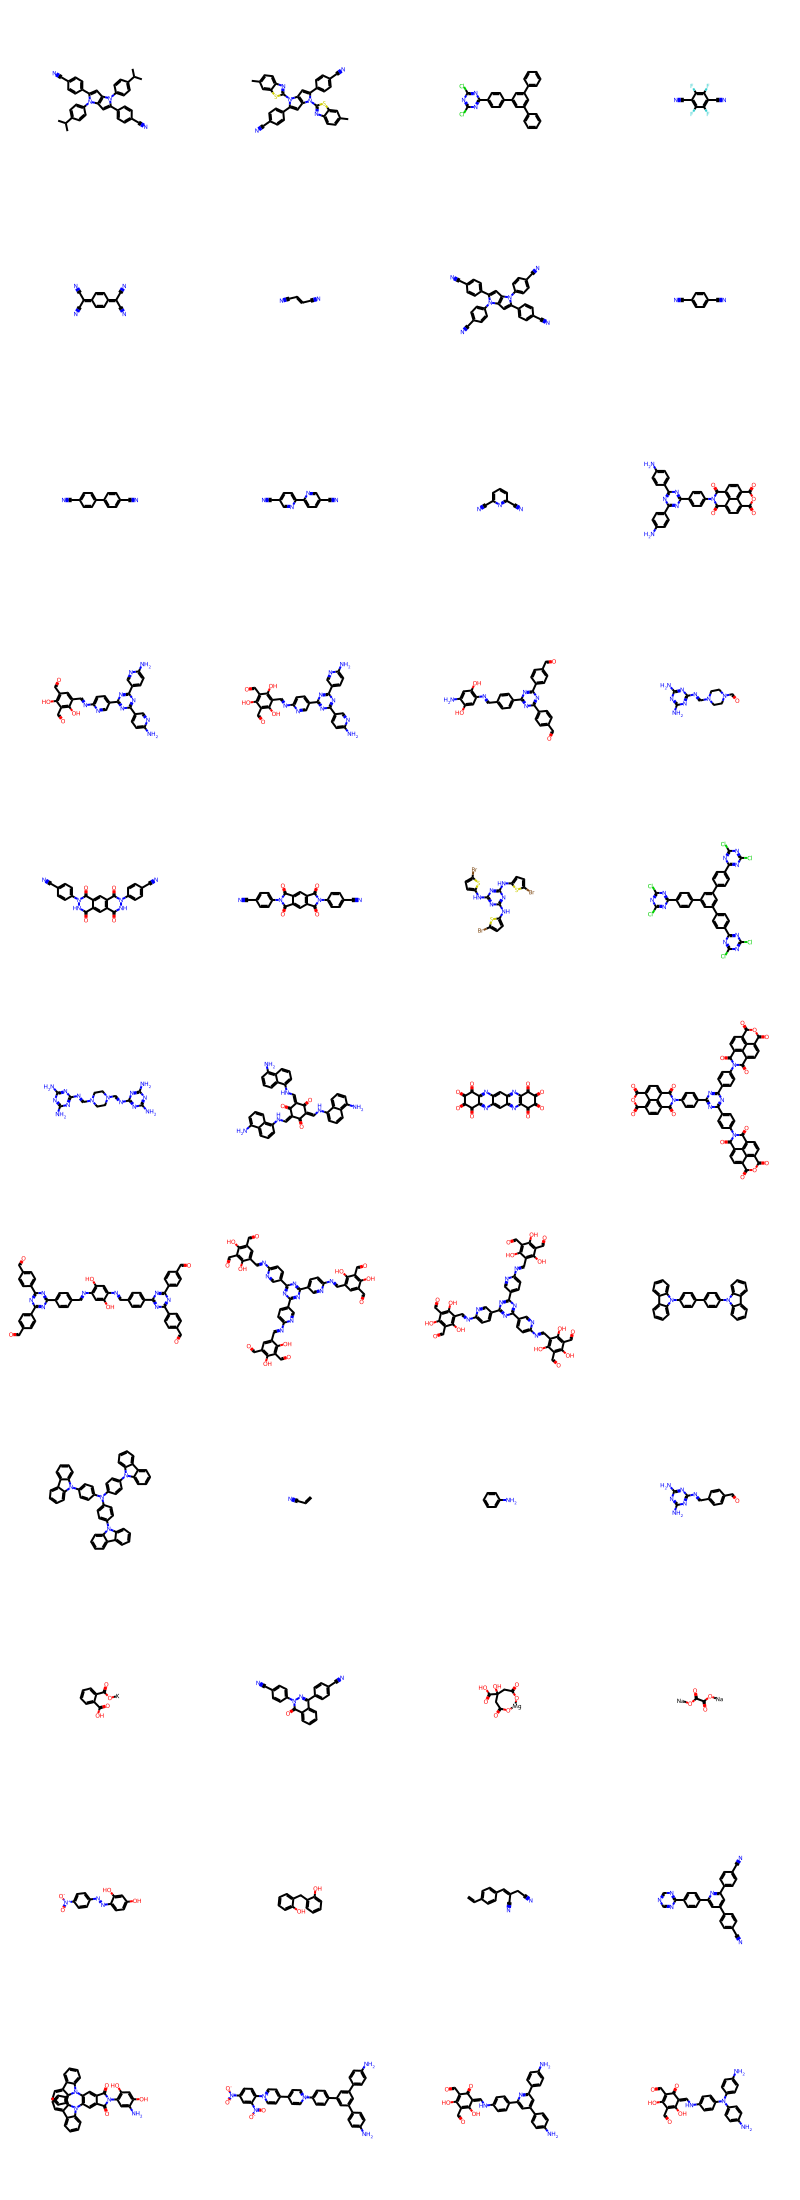

2 423.0 589.0 11


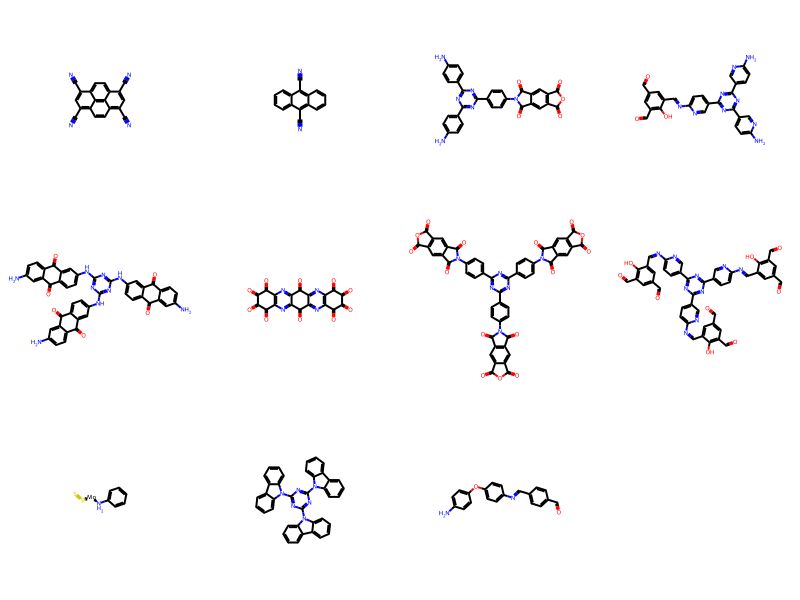

3 628.0 724.0 3


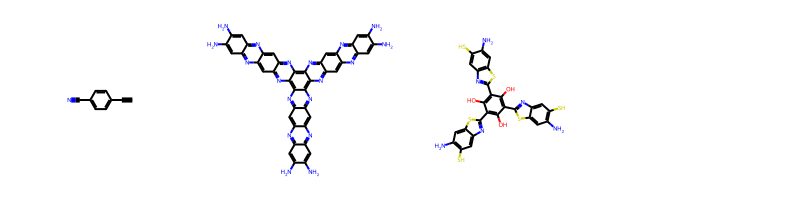

5 1236.0 1236.0 1


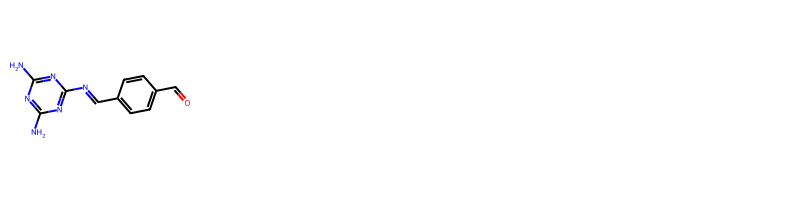

In [6]:
import numpy as np
from rdkit.Chem import Draw
from rdkit import Chem

df['bins'] = bins
unique_bins = sorted(np.unique(bins.tolist()))
for b in unique_bins:
    df_small = df[df['bins'] == b]
    print(b, df_small['capacity_max'].min(), df_small['capacity_max'].max(), len(df_small))
    smiles = df_small['smiles'].tolist()
    mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    display(Draw.MolsToGridImage(mols, molsPerRow=4))
    plt.show()

In [10]:
#point-biserial

import pandas as pd
import numpy as np
from scipy import stats

custom_features = '../../../data/processed_selected_custom_features/data_experts1.csv'
maccs_features = '../../../data/fingerprints_maccs/data_experts1.csv'
df_custom = pd.read_csv(custom_features)
df_custom.sort_values(by='smiles', inplace=True)
df_custom = df_custom[['flatness', 'ps']]
df_maccs = pd.read_csv(maccs_features)
df_maccs.sort_values(by='smiles', inplace=True)
df_maccs.drop(columns=['capacity_max', 'smiles'], inplace=True)

correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.pointbiserialr(df_maccs[col2], df_custom[col1]).correlation

correlation_matrix.T


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/scipy/stats/_stats_py.py:5657: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,flatness,ps
maccsfingerprint0,NaN,NaN
maccsfingerprint1,NaN,NaN
maccsfingerprint2,NaN,NaN
maccsfingerprint3,NaN,NaN
maccsfingerprint4,NaN,NaN
...,...,...
maccsfingerprint161,0.277431,0.343533
maccsfingerprint162,0.277431,0.343533
maccsfingerprint163,0.420592,0.667015
maccsfingerprint164,0.277431,0.343533


In [19]:
import pandas as pd
import numpy as np
from scipy import stats
data_names = ['experts1', 'experts2', ]#'experts3', 'saad', 'zhu']
custom_features = [f'../../../data/processed_selected_custom_features/data_{dname}.csv' for dname in data_names]
maccs_features = [f'../../../data/fingerprints_maccs/data_{dname}.csv' for dname in data_names]
df_custom = pd.concat([pd.read_csv(cf) for cf in custom_features], ignore_index=True)
df_custom.sort_values(by='smiles', inplace=True)
df_custom = df_custom[['flatness', 'ps']]
df_maccs = pd.concat([pd.read_csv(cf) for cf in maccs_features], ignore_index=True)
df_maccs.sort_values(by='smiles', inplace=True)
df_maccs.drop(columns=['capacity_max', 'smiles'], inplace=True)
df_maccs.describe()
correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.pointbiserialr(df_maccs[col2], df_custom[col1]).correlation
#
correlation_matrix.T

/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/scipy/stats/_stats_py.py:5657: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,flatness,ps
maccsfingerprint0,NaN,NaN
maccsfingerprint1,NaN,NaN
maccsfingerprint2,NaN,NaN
maccsfingerprint3,NaN,NaN
maccsfingerprint4,NaN,NaN
...,...,...
maccsfingerprint161,0.171201,0.247477
maccsfingerprint162,0.171201,0.247477
maccsfingerprint163,0.42096,0.604048
maccsfingerprint164,0.171201,0.247477


In [20]:
correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.spearmanr(df_maccs[col2], df_custom[col1]).correlation
#
correlation_matrix.T

/tmp/ipykernel_4497/43190432.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation_matrix.iloc[i, j] = stats.spearmanr(df_maccs[col2], df_custom[col1]).correlation


,flatness,ps
maccsfingerprint0,NaN,NaN
maccsfingerprint1,NaN,NaN
maccsfingerprint2,NaN,NaN
maccsfingerprint3,NaN,NaN
maccsfingerprint4,NaN,NaN
...,...,...
maccsfingerprint161,0.196502,0.252646
maccsfingerprint162,0.196502,0.252646
maccsfingerprint163,0.422434,0.629542
maccsfingerprint164,0.196502,0.252646


In [16]:
f_to_remove = []
for i, col in enumerate(df_maccs.columns):
    if df_maccs[col].max() == df_maccs[col].min():
        f_to_remove.append(col)
f_to_remove

['maccsfingerprint0',
 'maccsfingerprint1',
 'maccsfingerprint2',
 'maccsfingerprint3',
 'maccsfingerprint4',
 'maccsfingerprint5',
 'maccsfingerprint7',
 'maccsfingerprint8',
 'maccsfingerprint10',
 'maccsfingerprint11',
 'maccsfingerprint12',
 'maccsfingerprint13',
 'maccsfingerprint14',
 'maccsfingerprint15',
 'maccsfingerprint18',
 'maccsfingerprint19',
 'maccsfingerprint20',
 'maccsfingerprint21',
 'maccsfingerprint22',
 'maccsfingerprint25',
 'maccsfingerprint26',
 'maccsfingerprint28',
 'maccsfingerprint29',
 'maccsfingerprint30',
 'maccsfingerprint36',
 'maccsfingerprint38',
 'maccsfingerprint39',
 'maccsfingerprint47',
 'maccsfingerprint67',
 'maccsfingerprint107',
 'maccsfingerprint114',
 'maccsfingerprint115']

In [18]:
new_dir = '../../../data/selected_maccs'
import os
os.makedirs(new_dir, exist_ok=True)
for data_name in data_names:
    print(data_name)
    df = pd.read_csv(f'../../../data/fingerprints_maccs/data_{data_name}.csv')
    print(df.head())
    df.drop(columns=f_to_remove, inplace=True)
    df.to_csv(f'{new_dir}/data_{data_name}.csv', index=False)

experts1
   maccsfingerprint0  maccsfingerprint1  maccsfingerprint2  maccsfingerprint3  \
0                  0                  0                  0                  0   
1                  0                  0                  0                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  0   

   maccsfingerprint4  maccsfingerprint5  maccsfingerprint6  maccsfingerprint7  \
0                  0                  0                  0                  0   
1                  0                  0                  0                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  0   

   maccsfingerpri